Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.


Tasks:
1. Data Preparation:


In [230]:
#Load the dataset
import pandas as pd

In [231]:
df=pd.read_excel('/content/heart_disease.xlsx',sheet_name='Heart_disease')

In [232]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [233]:
df.shape

(908, 13)

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


2. Exploratory Data Analysis (EDA):

In [235]:
# check for missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [236]:
# replacing missing values
mode=df['oldpeak'].mode()

In [237]:
df.fillna({'oldpeak':mode[0]},inplace=True)

In [238]:
# checking duplicates
df.duplicated().any()

True

<Axes: >

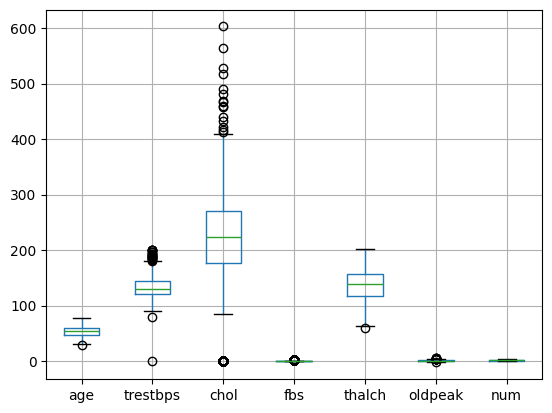

In [239]:
# checking for outliers
df.boxplot()

In [240]:
# outlier capping
def outlier_capping(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[column]=df[column].apply(lambda x:lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)
for i in ('trestbps','chol'):
  outlier_capping(df,i)


<Axes: ylabel='Count'>

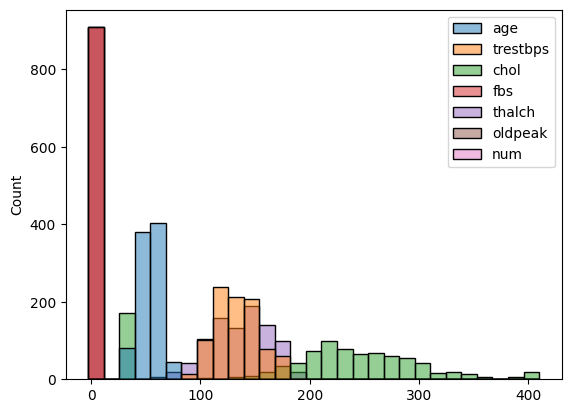

In [241]:
# data distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df)

In [242]:
num_col=[i for i in df.columns if df[i].dtypes!='O']
num_col

['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'num']

<Axes: >

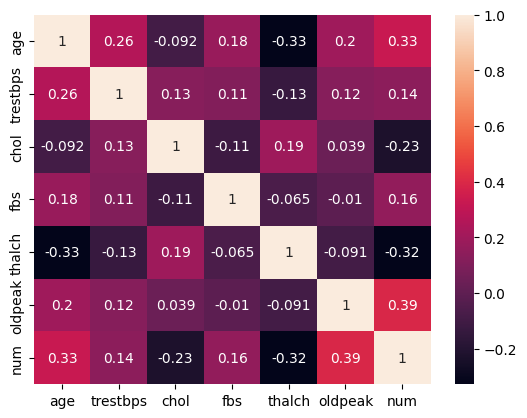

In [243]:
#correlation
corr=df[num_col].corr()
sns.heatmap(corr,annot=True)

3. Feature Engineering:

In [244]:
# target is num
target=df['num']
target.head()

,num
0,0
1,0
2,0
3,0
4,0


In [245]:
# the rest all are features
features=df.drop(columns='num')
features.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect
1,41,Male,atypical angina,135.0,203.0,False,normal,132,False,0.0,flat,fixed defect
2,57,Male,asymptomatic,140.0,192.0,False,normal,148,False,0.4,flat,fixed defect
3,52,Male,typical angina,118.0,186.0,False,lv hypertrophy,190,False,0.0,flat,fixed defect
4,57,Male,asymptomatic,110.0,201.0,False,normal,126,True,1.5,flat,fixed defect


In [246]:
num_col.remove('num')
cat_col=[i for i in features.columns if i not in num_col]

In [247]:
print(num_col,cat_col)

['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak'] ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal']


In [248]:
#labeling
cat_col_lab=pd.get_dummies(features[cat_col],dtype='int')
cat_col_lab.head()

,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True,exang_FALSE,exang_TURE,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,0,1,0,0,0,1,1,0,0,1,0,0,0,1,0,0,1,0,0
1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0
2,0,1,1,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0
3,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0
4,0,1,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0


In [249]:

# scaling
from sklearn.preprocessing import StandardScaler
sta_sca=StandardScaler()
num_cal_sca=pd.DataFrame(sta_sca.fit_transform(features[num_col]),columns=sta_sca.get_feature_names_out())


In [250]:
num_cal_sca.head()

,age,trestbps,chol,fbs,thalch,oldpeak
0,1.006027,0.607417,0.264845,1.976894,0.524183,1.362102
1,-1.397560,0.089009,-0.045006,-0.505844,-0.147705,-0.769653
2,0.350503,0.348213,-0.158618,-0.505844,0.449529,-0.398913
3,-0.195767,-0.792285,-0.220589,-0.505844,2.017268,-0.769653
4,0.350503,-1.207012,-0.065663,-0.505844,-0.371668,0.620622


In [251]:
features_new=pd.concat([num_cal_sca,cat_col_lab],axis=1)
features_new.head()

,age,trestbps,chol,fbs,thalch,oldpeak,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,...,exang_False,exang_True,exang_FALSE,exang_TURE,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,1.006027,0.607417,0.264845,1.976894,0.524183,1.362102,0,1,0,0,...,1,0,0,0,1,0,0,1,0,0
1,-1.397560,0.089009,-0.045006,-0.505844,-0.147705,-0.769653,0,1,0,1,...,1,0,0,0,0,1,0,1,0,0
2,0.350503,0.348213,-0.158618,-0.505844,0.449529,-0.398913,0,1,1,0,...,1,0,0,0,0,1,0,1,0,0
3,-0.195767,-0.792285,-0.220589,-0.505844,2.017268,-0.769653,0,1,0,0,...,1,0,0,0,0,1,0,1,0,0
4,0.350503,-1.207012,-0.065663,-0.505844,-0.371668,0.620622,0,1,1,0,...,0,1,0,0,0,1,0,1,0,0


4. Decision Tree Classification:

In [252]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report

In [253]:
x_train,x_test,y_train,y_test=train_test_split(features_new,target,train_size=0.80,random_state=100)

In [254]:
dec_tree=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=4)

In [255]:
dec_tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [256]:
y_pred=dec_tree.predict(x_test)

In [257]:
accuracy_score(y_test,y_pred)

0.5769230769230769

In [258]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.87      0.79        85
           1       0.39      0.47      0.43        49
           2       0.29      0.10      0.14        21
           3       0.46      0.26      0.33        23
           4       0.00      0.00      0.00         4

    accuracy                           0.58       182
   macro avg       0.37      0.34      0.34       182
weighted avg       0.53      0.58      0.54       182



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5. Hyperparameter Tuning:

In [259]:
dec_tree1=DecisionTreeClassifier(criterion='entropy',splitter='random',max_depth=4)

In [260]:
dec_tree1.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, splitter='random')

In [261]:
y_pred1=dec_tree1.predict(x_test)

In [262]:
accuracy_score(y_test,y_pred1)

0.5659340659340659

In [263]:
dec_tree2=DecisionTreeClassifier(criterion='entropy',splitter='random',max_depth=3)

In [264]:
dec_tree2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, splitter='random')

In [265]:
y_pred2=dec_tree2.predict(x_test)

In [266]:
accuracy_score(y_test,y_pred2)

0.5824175824175825

In [267]:
x_train1,x_test1,y_train1,y_test1=train_test_split(features_new,target,train_size=0.75,random_state=100)

In [268]:
dec_tree3=DecisionTreeClassifier(criterion='entropy',splitter='best',max_depth=4)

In [269]:
dec_tree3.fit(x_train1,y_train1)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [270]:
y_pred3=dec_tree3.predict(x_test1)

In [271]:
accuracy_score(y_test1,y_pred3)

0.5198237885462555

In [272]:
dec_tree4=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=4)

In [273]:
dec_tree4.fit(x_train1,y_train1)

DecisionTreeClassifier(max_depth=4)

In [274]:
y_pred4=dec_tree4.predict(x_test1)

In [275]:
accuracy_score(y_test1,y_pred4)

0.5330396475770925

6. Model Evaluation and Analysis:

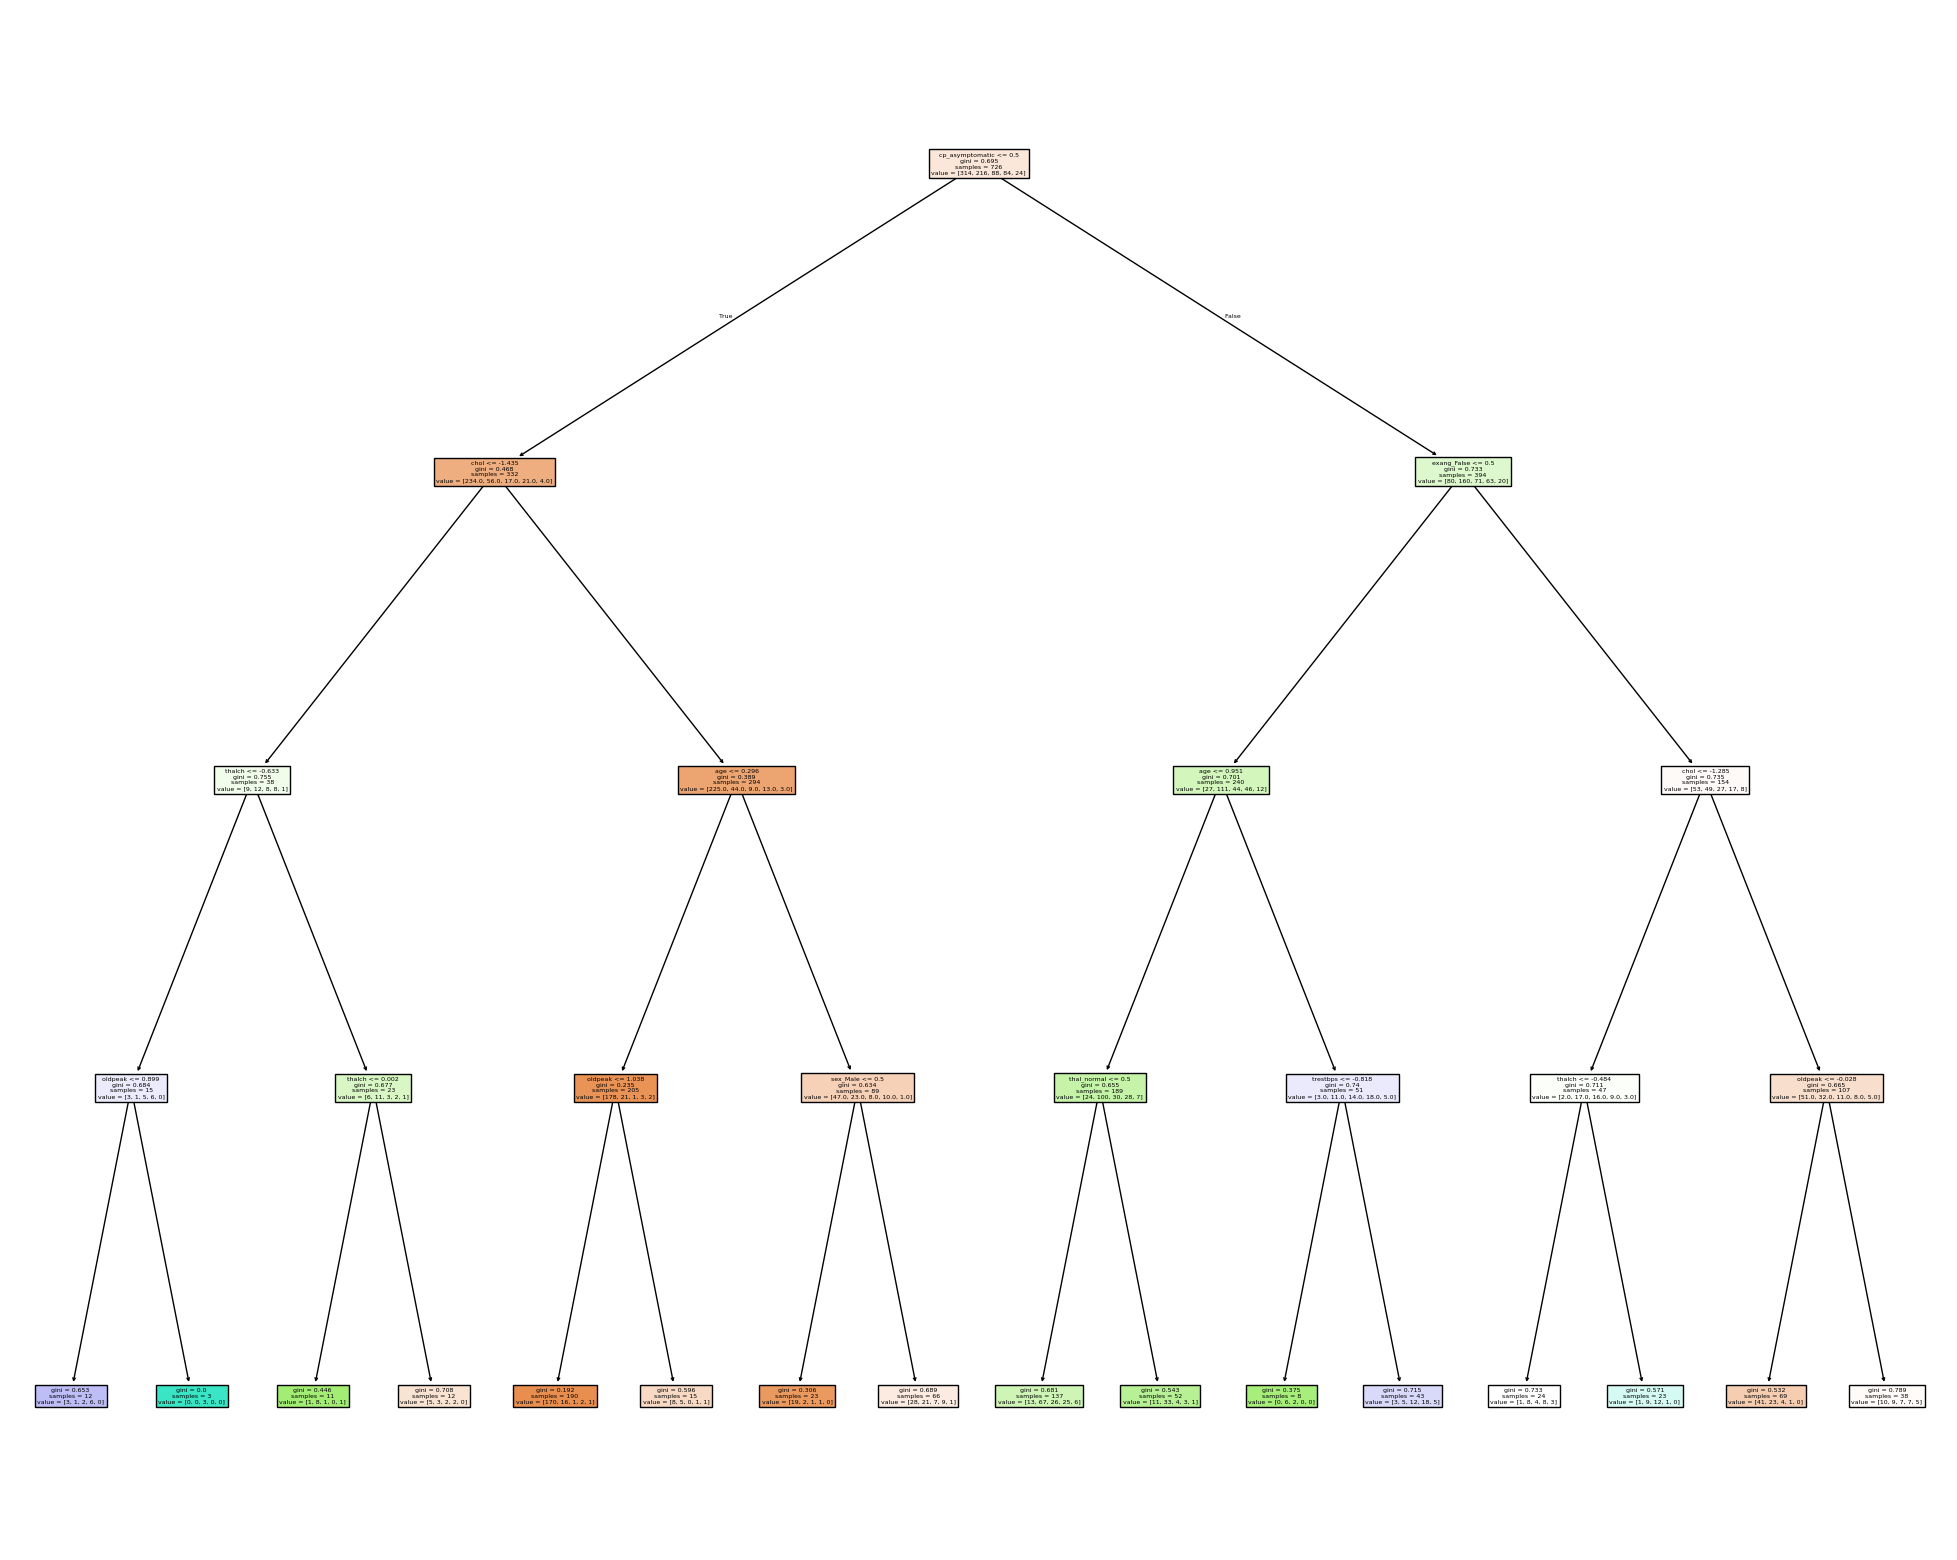

In [276]:
#visualize tree
plt.figure(figsize=(25,20))
plot_tree(dec_tree,feature_names=list(features_new),max_depth=4,filled=True);
plt.show()

Interview Questions:

In [277]:
#common hyperparameters of decision tree models, and how do they affect the model's performance?
'''
The parameters of decision tree model are
---- criterion(entropy,gini)
---- splitter(best,random)
---- max_depth

These parameters can control overfitting and underfitting issues.
By tuning these parameters ,performance can be improved.
'''

'\nThe parameters of decision tree model are\n---- criterion(entropy,gini)\n---- splitter(best,random)\n---- max_depth\n\nThese parameters can control overfitting and underfitting issues.\nBy tuning these parameters ,performance can be improved.\n'

In [278]:
#What is the difference between the Label encoding and One-hot encoding?
'''
Label encoding:
---- Label encoding is one of the labeling techinques of eda process.
---- It is applied to categorical column which can be ordered or ranked(ordinal column).

One-hot encoding:
---- One hot encoding is one of the labeling techinques of eda process.
---- It is applied to categorical column which cannot be ordered or ranked(nominal column).
'''

'\nLabel encoding:\n---- Label encoding is one of the labeling techinques of eda process.\n---- It is applied to categorical column which can be ordered or ranked(ordinal column).\n\nOne-hot encoding:\n---- One hot encoding is one of the labeling techinques of eda process.\n---- It is applied to categorical column which cannot be ordered or ranked(nominal column).\n'